## Data pre-process:

##### Process Listing

1. Loading the Data
2. dealing with data in the wrong format 
3. dealing with missing values
4. Data Transformation
5. check the correlation between values
6. Save the data for post-processing

### Loading the data

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import pickle

In [122]:
main_data = pd.read_csv(r"source_data/INDUSTRY_COPPER.csv")
main_data.head()

,id,item_date,quantity tons,customer,country,status,item type,application,thickness,width,material_ref,product_ref,delivery date,selling_price
0,EC06F063-9DF0-440C-8764-0B0C05A4F6AE,20210401.0,54.151139,30156308.0,28.0,Won,W,10.0,2.00,1500.0,DEQ1 S460MC,1670798778,20210701.0,854.00
1,4E5F4B3D-DDDF-499D-AFDE-A3227EC49425,20210401.0,768.024839,30202938.0,25.0,Won,W,41.0,0.80,1210.0,0000000000000000000000000000000000104991,1668701718,20210401.0,1047.00
2,E140FF1B-2407-4C02-A0DD-780A093B1158,20210401.0,386.127949,30153963.0,30.0,Won,WI,28.0,0.38,952.0,S0380700,628377,20210101.0,644.33
3,F8D507A0-9C62-4EFE-831E-33E1DA53BB50,20210401.0,202.411065,30349574.0,32.0,Won,S,59.0,2.30,1317.0,DX51D+ZM310MAO 2.3X1317,1668701718,20210101.0,768.00
4,4E1C4E78-152B-430A-8094-ADD889C9D0AD,20210401.0,785.526262,30211560.0,28.0,Won,W,10.0,4.00,2000.0,2_S275JR+AR-CL1,640665,20210301.0,577.00


In [123]:
# check for how many original data in the pd.DataFrame
main_data.shape

(181673, 14)

## dealing with data in the wrong format 

In [124]:
# handling data and time
main_data['item_date'] = pd.to_datetime(main_data['item_date'], format='%Y%m%d', errors='coerce').dt.date

In [125]:
# handling the categorical variable
main_data['quantity tons'] = pd.to_numeric(main_data['quantity tons'], errors='coerce')
main_data['customer'] = pd.to_numeric(main_data['customer'], errors='coerce')
main_data['country'] = pd.to_numeric(main_data['country'], errors='coerce')
main_data['application'] = pd.to_numeric(main_data['application'], errors='coerce')
main_data['thickness'] = pd.to_numeric(main_data['thickness'], errors='coerce')
main_data['width'] = pd.to_numeric(main_data['width'], errors='coerce')
main_data['material_ref'] = main_data['material_ref'].str.lstrip('0')
main_data['product_ref'] = pd.to_numeric(main_data['product_ref'], errors='coerce')
main_data['delivery date'] = pd.to_datetime(main_data['delivery date'], format='%Y%m%d', errors='coerce').dt.date
main_data['selling_price'] = pd.to_numeric(main_data['selling_price'], errors='coerce')

## dealing with missing values

In [126]:
# check for number of missing values
main_data.isnull().sum()

id                   2
item_date            3
quantity tons        1
customer             1
country             28
status               2
item type            0
application         24
thickness            1
width                0
material_ref     77919
product_ref          0
delivery date        3
selling_price        1
dtype: int64

In [127]:
# material_ref - 77919 is 42.89% of the whole data. can't be dropped instead replacing it with 'None'
warnings.filterwarnings("ignore")
main_data['material_ref'].fillna('none', inplace=True)

In [128]:
# remove all the Null values in this DataFrame
main_data.dropna(inplace=True)

In [129]:
# Check again for the missing values.
main_data.isnull().sum()

id               0
item_date        0
quantity tons    0
customer         0
country          0
status           0
item type        0
application      0
thickness        0
width            0
material_ref     0
product_ref      0
delivery date    0
selling_price    0
dtype: int64

## Data Transformation

In [130]:
plot_data = main_data.copy()

In [131]:
# plot the data in a dist plot for identifying skewed data

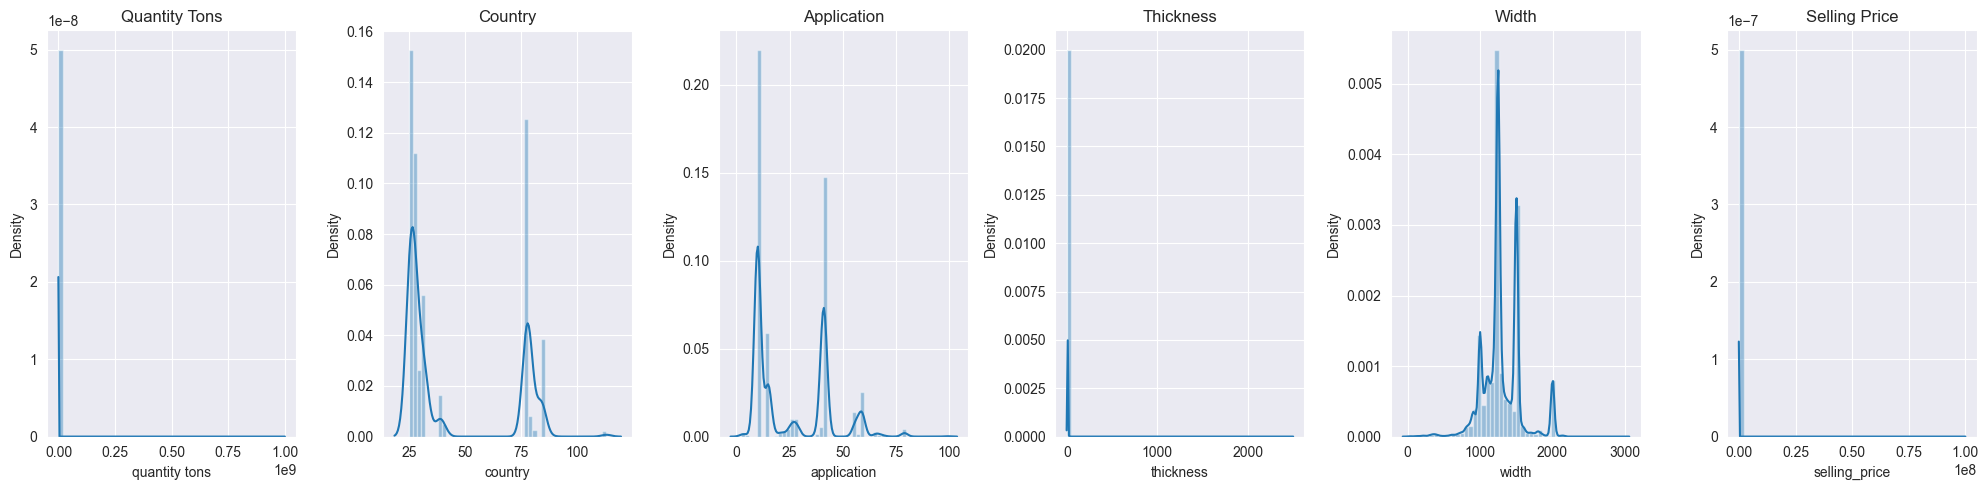

In [132]:
# Create a figure with 1 row and 6 columns
fig, axes = plt.subplots(1, 6, figsize=(20, 5))

# Plot each distribution in a separate subplot
sns.distplot(plot_data['quantity tons'], ax=axes[0])
axes[0].set_title('Quantity Tons')

sns.distplot(plot_data['country'], ax=axes[1])
axes[1].set_title('Country')

sns.distplot(plot_data['application'], ax=axes[2])
axes[2].set_title('Application')

sns.distplot(plot_data['thickness'], ax=axes[3])
axes[3].set_title('Thickness')

sns.distplot(plot_data['width'], ax=axes[4])
axes[4].set_title('Width')

sns.distplot(plot_data['selling_price'], ax=axes[5])
axes[5].set_title('Selling Price')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [133]:
# "Quantity_tons", "thickness" and "selling price" all three is skewed

In [134]:
# Normalize all three of the data by replacing with nan

mask1 = plot_data['selling_price'] <= 0
print(f"selling_price => {mask1.sum()}")
plot_data.loc[mask1, 'selling_price'] = np.nan

mask1 = plot_data['quantity tons'] <= 0
print(f"quantity tons => {mask1.sum()}")
plot_data.loc[mask1, 'quantity tons'] = np.nan

mask1 = plot_data['thickness'] <= 0
print(f"thickness => {mask1.sum()}")
plot_data.loc[mask1, 'thickness'] = np.nan

selling_price => 7
quantity tons => 4
thickness => 0


In [135]:
plot_data.isnull().sum()

id               0
item_date        0
quantity tons    4
customer         0
country          0
status           0
item type        0
application      0
thickness        0
width            0
material_ref     0
product_ref      0
delivery date    0
selling_price    7
dtype: int64

In [136]:
plot_data.dropna(inplace=True)
plot_data.isnull().sum()

id               0
item_date        0
quantity tons    0
customer         0
country          0
status           0
item type        0
application      0
thickness        0
width            0
material_ref     0
product_ref      0
delivery date    0
selling_price    0
dtype: int64

#### log transformation

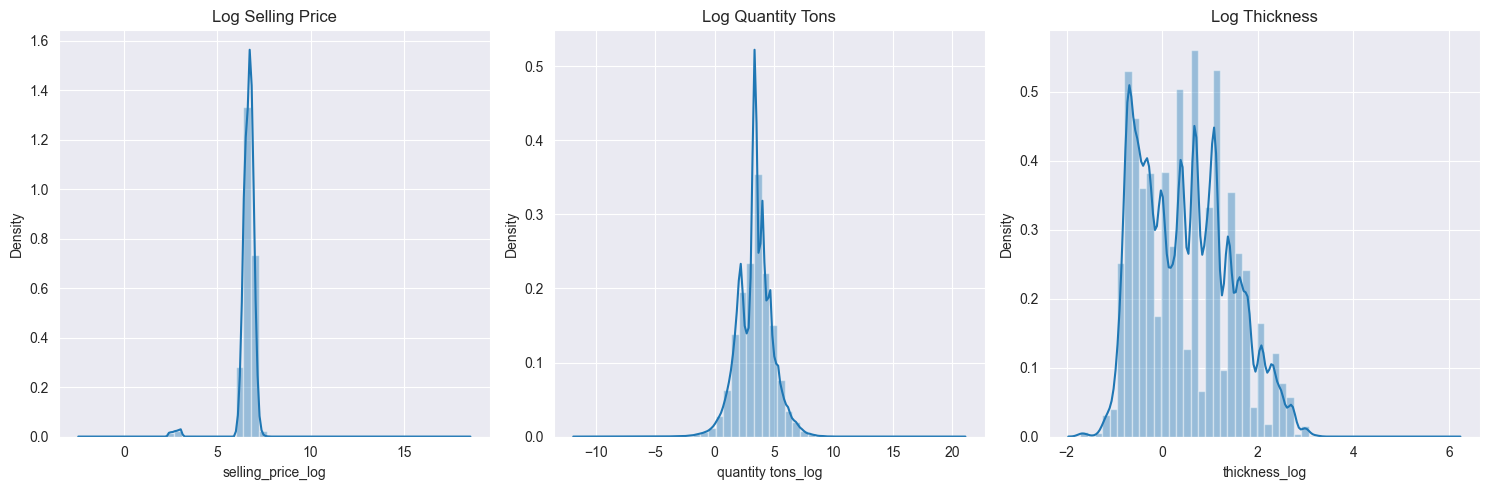

In [137]:
plot_data['selling_price_log'] = np.log(plot_data['selling_price'])
plot_data['quantity tons_log'] = np.log(plot_data['quantity tons'])
plot_data['thickness_log'] = np.log(plot_data['thickness'])

_ , axes = plt.subplots(1, 3, figsize=(15, 5))

sns.distplot(plot_data['selling_price_log'], ax=axes[0])
axes[0].set_title('Log Selling Price')

sns.distplot(plot_data['quantity tons_log'], ax=axes[1])
axes[1].set_title('Log Quantity Tons')

sns.distplot(plot_data['thickness_log'], ax=axes[2])
axes[2].set_title('Log Thickness')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

## check the correlation between values in the data

In [138]:
x=plot_data[['quantity tons_log','application','thickness_log',
             'width','selling_price_log','country','customer','product_ref']].corr()

<Axes: >

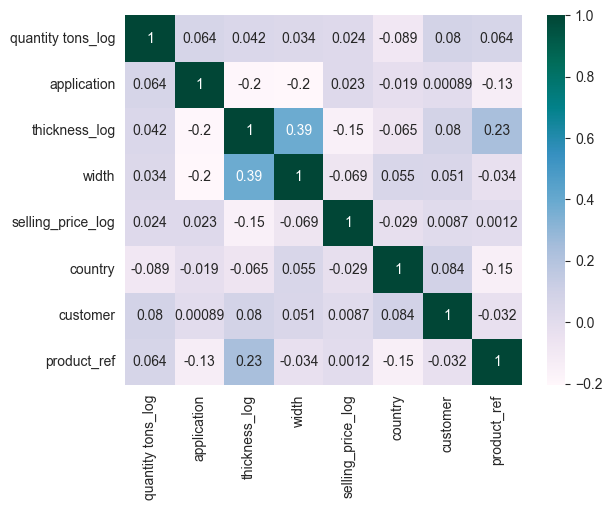

In [139]:
sns.heatmap(x, annot=True, cmap="PuBuGn")

## Load the data to a file

In [140]:
# for training and other  works

plot_data.to_csv('source_data/preprocessed_data.csv', index=False)

# Predicting the price

Predicting the price is a regression task.
here Decision tree regressor for fast and interpretable result. Because, it uses single tree from root to leaf.
Random forest regressor for better accuracy and stability. It takes multiple tree, so it takes much compute power.
Much compute power is not available here.

#### Decision tree regressor (Price_prediction)

In [141]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [142]:
piped_data = plot_data.copy()

In [143]:
# piped_data.reset_index(drop=True)
piped_data.head(2)

,id,item_date,quantity tons,customer,country,status,item type,application,thickness,width,material_ref,product_ref,delivery date,selling_price,selling_price_log,quantity tons_log,thickness_log
0,EC06F063-9DF0-440C-8764-0B0C05A4F6AE,2021-04-01,54.151139,30156308.0,28.0,Won,W,10.0,2.0,1500.0,DEQ1 S460MC,1670798778,2021-07-01,854.0,6.749931,3.991779,0.693147
1,4E5F4B3D-DDDF-499D-AFDE-A3227EC49425,2021-04-01,768.024839,30202938.0,25.0,Won,W,41.0,0.8,1210.0,104991,1668701718,2021-04-01,1047.0,6.953684,6.643822,-0.223144


In [144]:
# separate the data from the outcome
# 'id','customer', 'item_date','delivery date' are not the type of data that should affect outcome
# Item type and status are the only unencodable options, an
x = piped_data[['quantity tons_log','application','thickness_log','width','country','customer','product_ref',
                'status','item type']]
y = piped_data['selling_price_log']

#### encoding columns
```plaintext
  unique value columns
    - item type       7 
    - status         9
    - product_ref    33
    - application    30
    - country        17

product_ref, application, country are already numerical values, encoding for it is not needed.
item_type and status are Categorical with low cardinality, so going for OneHotEncoding.
```

In [145]:
x.head()

,quantity tons_log,application,thickness_log,width,country,customer,product_ref,status,item type
0,3.991779,10.0,0.693147,1500.0,28.0,30156308.0,1670798778,Won,W
1,6.643822,41.0,-0.223144,1210.0,25.0,30202938.0,1668701718,Won,W
2,5.956169,28.0,-0.967584,952.0,30.0,30153963.0,628377,Won,WI
3,5.310301,59.0,0.832909,1317.0,32.0,30349574.0,1668701718,Won,S
4,6.666354,10.0,1.386294,2000.0,28.0,30211560.0,640665,Won,W


In [146]:
print(x.shape,y.shape)

(181620, 9) (181620,)


In [147]:
#### 'Item type' and 'status' are falling into few categories, 'material_ref' is not included in df
#### 'Item type' has 'won' and 'lost', 'Not lost for AM','To be approved'

ohe_1 = OneHotEncoder(handle_unknown='ignore')
ohe_1.fit(x[['status']])
paired_1 = ohe_1.transform(x[['status']]).toarray()

In [148]:
ohe_2 = OneHotEncoder(handle_unknown='ignore')
ohe_2.fit(x[['item type']])
paired_2 = ohe_2.transform(x[['item type']]).toarray()

In [149]:
# combining features x_ohe has 'item type' and 'status' encoded.  add other with it.
x_combined = np.hstack((x[['quantity tons_log','application','thickness_log','width','country',
                           'customer','product_ref']].values, paired_1, paired_2))

In [150]:
# Scale the combined features
scaler = StandardScaler()
x = scaler.fit_transform(x_combined)

In [151]:
# Split the data into training and testing data sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

In [152]:
# Train a DecisionTreeRegressor to predict selling_price
DTR = DecisionTreeRegressor(random_state=42)

### hyperparameters
Hyperparam_grid = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']
}

In [153]:
# hyperparameters
Hyperparam_grid = {
    'max_depth': [3, 5, 10, 20,50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'] # ,'criterion': ['squared_error', 'absolute_error', 'friedman_mse']
}

In [154]:
# Run next two cells continuously.
start_time = time.time() # Start timer

In [155]:
# GridSearchCV

grid_search = GridSearchCV(DTR, Hyperparam_grid, cv=5, scoring='r2',n_jobs=-1)
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, 20, 50],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2')

In [156]:

end_time = time.time() # End timer

# Calculate elapsed time
elapsed_time = end_time - start_time
print(f"GridSearchCV took {elapsed_time:.2f} seconds")

GridSearchCV took 10.51 seconds


In [157]:
# Best Model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [158]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)  # Mean Absolute Error
r2 = r2_score(y_test, y_pred)   # R2 score
map_error = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # Mean Absolute Percentage Error

In [159]:
print("Best hyperparameters:", grid_search.best_params_)

Best hyperparameters: {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10}


In [160]:
print('Mean Squared Error:', mse)
print('R-Squared:', r2)
print('Mean Absolute Percentage Error:', map_error, "%")

Mean Squared Error: 0.026617606293260855
R-Squared: 0.9173805058454183
Mean Absolute Percentage Error: 1.957155129354772 %


Mean Squared Error: 0.028348808411033363
R-Squared: 0.9120069556593552
Mean Absolute Percentage Error: 2.017347296074443 %

In [161]:
def price_prediction(quantity_log, application, thickness_log, width, country, customer, product_ref, item_type, status):
    new_sample = np.array([[np.log(quantity_log), application, np.log(thickness_log), width, country,
                            customer,product_ref, item_type, status]])
    new_sample_ohe1 = ohe_1.transform(new_sample[:, [7]]).toarray()
    new_sample_ohe2 = ohe_2.transform(new_sample[:, [8]]).toarray()
    new_sample_stack = np.hstack((new_sample[:, [0,1,2,3,4,5,6]], new_sample_ohe1, new_sample_ohe2))
    new_sample1 = scaler.transform(new_sample_stack)
    new_pred = best_model.predict(new_sample1)
    print('Predicted selling price:', np.exp(new_pred))

In [162]:
# previous pred - 554.14247792
# act ans - 854
price_prediction(quantity_log = 54.151139, application = 10,
                 thickness_log= 2, width = '1500', country = 28, customer = 30156308, 
                 product_ref = '1670798778', item_type = 'W', status = 'Won')

Predicted selling price: [754.61247343]


In [163]:
# act ans - 1047
price_prediction(quantity_log = 768.024839, application = 41,
                 thickness_log= 0.80, width = '1210', country = 25, customer = 30202938, 
                 product_ref = '1668701718', item_type = 'W', status = 'Won')

Predicted selling price: [1024.324067]


In [164]:
# act ans - 1047
price_prediction(quantity_log = 386.127949, application = 28,
                 thickness_log= 0.38, width = '952', country = 30, customer = 30153963, 
                 product_ref = '628377', item_type = 'WI', status = 'Won')

Predicted selling price: [803.03501244]


#### Saving the model

In [165]:
def save_it(artifact, filename):
    filepath = f"model_data/{filename}.pkl"
    with open(filepath, 'wb') as file:
        pickle.dump(artifact, file)
    print(f"saved {filename}.pkl")

In [166]:
save_it(best_model,'dtr_model')
save_it(scaler,'dtr_scaler')
save_it(ohe_1,'dtr_ohe_1')
save_it(ohe_2,'dtr_ohe_2')

saved dtr_model.pkl
saved dtr_scaler.pkl
saved dtr_ohe_1.pkl
saved dtr_ohe_2.pkl


## DECISION TREE CLASSIFIER

Here we need to predict Won or Lost in only. No need add other in DataFrame.

In [167]:
cls_df = piped_data[piped_data['status'].isin(['Won', 'Lost'])]

In [168]:
# how much missing in won/lost drop
len(piped_data) - len(cls_df)

31193

In [169]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelBinarizer
from sklearn.metrics import confusion_matrix

In [170]:
X = cls_df[['quantity tons_log','selling_price_log','item type','application','thickness_log',
         'width','country','customer','product_ref']]
Y = cls_df['status']

In [171]:
# Don't previously encode 'item type' it contains other than won/loss data which is not ordered to 'cls_df' here.
# encoding categorical variables
ohe = OneHotEncoder(handle_unknown='ignore')
ohe.fit(X[['item type']])
X_ohe = ohe.fit_transform(X[['item type']]).toarray()

In [172]:
be = LabelBinarizer()
be.fit(Y) 
y = be.fit_transform(Y)

In [173]:
# independent features after encoding
X = np.hstack((X[['quantity tons_log', 'selling_price_log','application', 
                       'thickness_log', 'width','country','customer','product_ref']].values, X_ohe))


In [174]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [175]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [176]:
# decision tree classifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)


In [177]:

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

Accuracy: 0.9120853553147643
Confusion Matrix:
[[ 5689  1313]
 [ 1332 21752]]


In [178]:
# Predict the status for a new sample
# 'quantity tons_log','selling_price_log','application','thickness_log','width','country','customer','product_ref','item type'

def status_classification(quantity, sale_price, application, thickness, width, country, customer, product_ref, item_type):
    new_sample = np.array([[np.log(quantity), np.log(sale_price), application, np.log(thickness),
                            width,country,customer,product_ref,item_type]])
    new_sample_ohe = ohe.transform(new_sample[:, [8]]).toarray()
    new_sample = np.hstack((new_sample[:, [0,1,2, 3, 4, 5, 6,7]], new_sample_ohe))
    new_sample = scaler.transform(new_sample)
    new_pred = dtc.predict(new_sample)
    if new_pred==1:
        print('The status is: Won')
    else:
        print('The status is: Lost')

In [179]:
status_classification(quantity=700, sale_price=956, application=10, thickness=1500, width=28.0, country=28, 
                      customer=30202938, product_ref=1670798778,item_type='W')

The status is: Won


#### Saving the model
(Decision Tree Classifier)

In [180]:
save_it(dtc,'dtc_model')
save_it(scaler,'dtc_scaler')
save_it(ohe,'dtc_encode')

saved dtc_model.pkl
saved dtc_scaler.pkl
saved dtc_encode.pkl
